In [86]:
import pandas as pd
df=pd.read_csv("data/creditcard.csv")
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [87]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

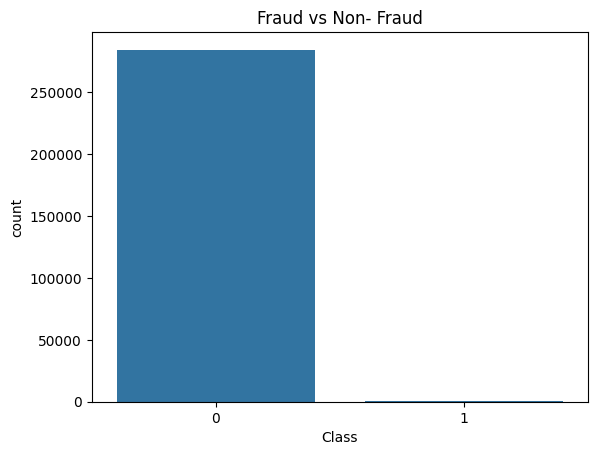

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Class',data=df)
plt.title("Fraud vs Non- Fraud")
plt.show()

In [89]:
fraud=df['Class'].value_counts()
print(fraud)
print("\nFraud Percentage:")
print((fraud[1]/len(df))*100)

Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
0.1727485630620034


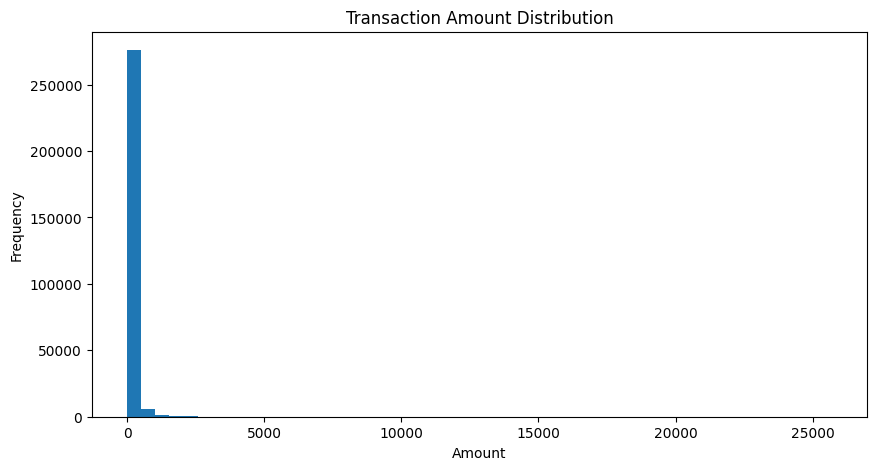

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df['Amount'],bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

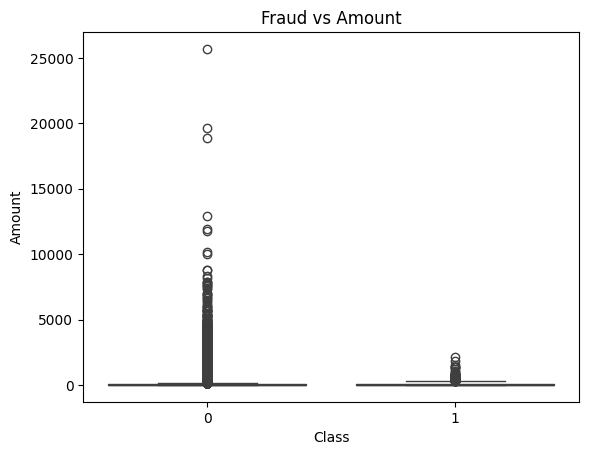

In [91]:
import seaborn as sns
sns.boxplot(x='Class',y='Amount',data=df)
plt.title("Fraud vs Amount")
plt.show()

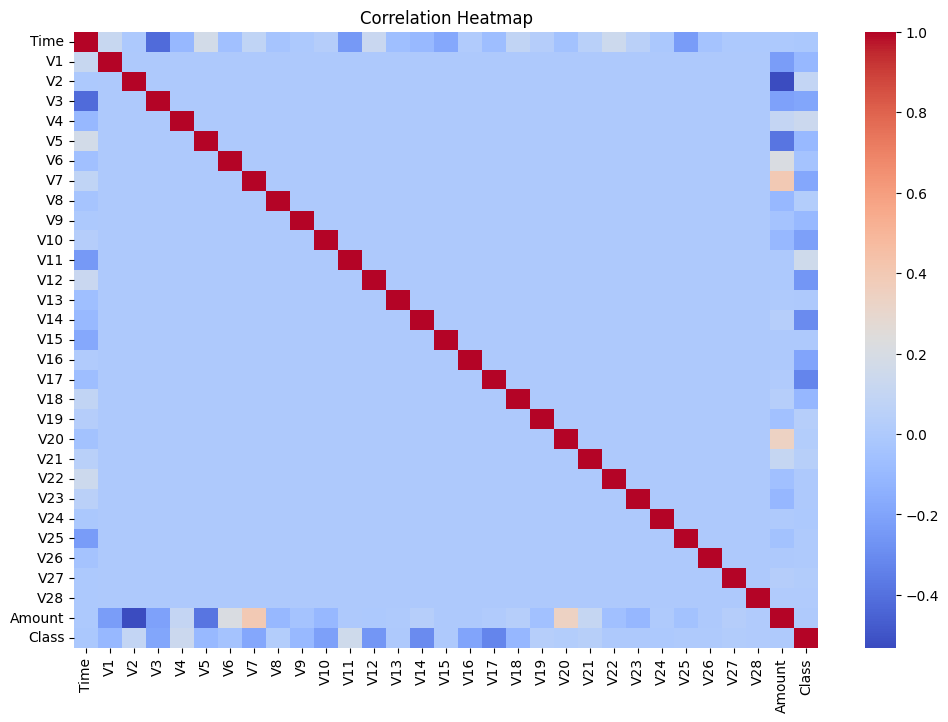

In [92]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [93]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [94]:
df=df.drop_duplicates()
print(df.shape)

(283726, 31)


In [95]:
df.to_csv("cleaned_dataset.csv",index=False)

In [96]:
X=df.drop('Class',axis=1)
y=df['Class']

In [97]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

In [98]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [99]:
pred=model.predict(X_test)

In [100]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,pred))

0.9995065731505305


In [101]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.71      0.82        90

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE



In [123]:
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [124]:
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,
y_train)

In [125]:
lr_model=LogisticRegression()
lr_model.fit(X_train_smote,y_train_smote)

LogisticRegression()

In [126]:
lr_pred=lr_model.predict(X_test)

In [132]:
print("Accuracy:",accuracy_score(y_test ,lr_pred))
print("Precision:",precision_score(y_test,lr_pred))
print("Recall:",recall_score(y_test,lr_pred))
print("F1 Score:",f1_score(y_test,lr_pred))

Accuracy: 0.9750643217143059
Precision: 0.05387205387205387
Recall: 0.8888888888888888
F1 Score: 0.10158730158730159


In [133]:
print(confusion_matrix(y_test,lr_pred))

[[55251  1405]
 [   10    80]]


In [134]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.05      0.89      0.10        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.54     56746
weighted avg       1.00      0.98      0.99     56746



In [135]:
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train_smote,y_train_smote)
dt_pred=dt_model.predict(X_test)

In [136]:
print("decision Tree Accuracy:",accuracy_score(y_test,dt_pred))

decision Tree Accuracy: 0.9979029358897543


In [137]:
rf_model=RandomForestClassifier()
rf_model.fit(X_train_smote,y_train_smote)
rf_pred=rf_model.predict(X_test)

In [138]:
print("Random Forest Accuracy:",accuracy_score(y_test,rf_pred))


Random Forest Accuracy: 0.9995594403129736


In [139]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.93      0.78      0.85        90

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [140]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote,y_train_smote)
xgb_pred=xgb_model.predict(X_test)

In [141]:
xgb_pred=xgb_model.predict(X_test)

In [145]:
models=pd.DataFrame({
    "Model":["Logistic Regression",
             "Decision Tree",
             "Random Forest",
             "XGBClassifier"],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
    ]
})
models

,Model,Accuracy
0,Logistic Regression,0.975064
1,Decision Tree,0.997903
2,Random Forest,0.999559
3,XGBClassifier,0.999401


In [148]:
joblib.dump(rf_model,"fraud_model.pkl")

['fraud_model.pkl']

In [150]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']